# TP7 : Régression linéaire

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA, la NMF, le MDS, l'Isomap et le KNN. Le présent TP utilisant la PCA, voici une cellule important la classe `PCA` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)) de la bibliothèque `sklearn`. Regardez bien la documentation. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [2]:
from sklearn.decomposition import PCA

Importez les jeux de données.

In [3]:
## from google.colab import files
## data_to_load = files.upload()
## import io
## df_prices = pd.read_csv(io.BytesIO(data_to_load['prices.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv("prix.csv")
y = df_prices.values

print(X.shape)
print(f"Nombre de prix : {len(y)}")
print(f"Prix min : {y.min():.2f}, Prix max : {y.max():.2f}")

(2535, 784)
Nombre de prix : 2535
Prix min : 25.94, Prix max : 194.54


---

## Introduction : de la classification à la régression

Dans le TP précédent, nous avons travaillé sur un problème de classification : prédire à quelle classe appartient une image (T-shirt, pantalon, robe, etc.). La sortie du modèle était une étiquette discrète parmi un ensemble fini de classes.

Nous abordons maintenant la régression : prédire une valeur continue. Dans notre cas, il s'agit de prédire le prix d'un vêtement à partir de l'image. La sortie du modèle est un nombre réel.

Le modèle le plus simple de régression est la régression linéaire. L'idée est de trouver un vecteur de poids tel que la prédiction pour une entrée donnée soit une combinaison linéaire des caractéristiques d'entrée.

Pour un jeu de données d'entraînement (matrice où chaque ligne est un exemple) et un vecteur des sorties cibles, le vecteur de poids optimal au sens des moindres carrés est donné par les équations normales. Cette formule suppose que la matrice des données soit de rang plein (toutes les colonnes sont linéairement indépendantes).

L'objectif de ce TP va consister en la création d'une classe permettant l'entraînement et la prédiction d'un modèle de régression linéaire. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [4]:
class MyLinearRegression:
    def __init__(self):
        # Attributs qui seront remplis lors de l'entraînement
        self.weights = None
        self.data = None
        self.output = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

1. Ajoutez à la classe MyLinearRegression une méthode `fit(self, data, output)` qui vérifie si data est de rang plein en utilisant `np.linalg.matrix_rank` (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html)**). Si le rang est strictement inférieur au nombre de colonnes, afficher un message d'erreur avec le rang et ne rien faire d'autre. Si le rang est plein, calculer `self.weights` avec les équations normales : $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$ en utilisant np.linalg.inv ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)) et stocker `data` et `output` dans `self.data` et `self.output`.

In [5]:
def fit(self,data,output):
    self.data=data
    self.output=output
    if(np.linalg.matrix_rank(data)<np.shape(data)[1]):
        raise ValueError(f"le rang de la matrice est {np.linalg.matrix_rank(data)}")
    
    self.data = data
    self.output = output
    self.weights = np.linalg.inv(np.matmul(data.T,data)) @ data.T @self.output
    
MyLinearRegression.fit = fit

2. Ajoutez une méthode `predict(self, data)` qui retourne les prédictions du modèle en utilisant les poids appris sur une matrice de données `data`.

In [6]:
def predict(self,data):
    return data @ self.weights
MyLinearRegression.predict = predict

3. Ajoutez une méthode `mse(self)` qui calcule et retourne l'erreur quadratique moyenne (Mean Squared Error) entre `self.output` et les prédictions sur `self.data` : $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [7]:
def mse(self):
    return np.mean((self.output-self.predict(self.data))**2)
MyLinearRegression.mse = mse

4. Ajoutez une méthode `r2(self)` qui calcule et retourne le coefficient de détermination $R^2$ entre `self.output` et les prédictions sur `self.data` : $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$ où $\bar{y}$ est la moyenne de y. Un $R^2$ de 1 indique une prédiction parfaite, un $R^2$ de 0 indique que le modèle ne fait pas mieux que prédire la moyenne, un $R^2$ négatif signifie que le modèle est moins performant que la prédiction constante à la moyenne.

In [8]:
def r2(self):
    return 1 - (self.mse())/(np.mean((self.output- np.mean(self.output))**2))
MyLinearRegression.r2 = r2

## Exercice 2

Créez une instance de MyLinearRegression, entraînez-la sur `X` et `y`, et observez ce qui se passe. Pourquoi l'entraînement échoue-t-il ? Réfléchissez à ce que signifie dans le contexte de notre dataset d'images de vêtements.

In [9]:
mlr = MyLinearRegression()
test= mlr.fit(X,y)
return mlr.r2()

ValueError: le rang de la matrice est 671

L'entraînement échoue car la matrice X n'est pas de rang plein : certaines colonnes (pixels) sont linéairement dépendantes, ce qui rend 
X.T X X.T
 X non inversible. Cela est dû au fait que plusieurs pixels sont constants ou très corrélés entre toutes les images

## Exercice 3

Une première approche pour résoudre le problème de rang consiste à projeter `X` dans un espace de dimension réduite en utilisant la PCA. Si on ne garde que $r$ composantes principales avec $r$ strictement inférieur au rang de `X`, alors la matrice projetée est garantie d'être de rang plein.

1. Utilisez la classe PCA de `sklearn` pour projeter `X` sur $r = 50$ composantes. Entraînez ensuite une `MyLinearRegression` sur les données projetées. Affichez le MSE et le $R^2$ obtenus. Les résultats vous semblent-ils satisfaisants ?

In [17]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)
mlr_pca = MyLinearRegression()
mlr_pca.fit(X_pca,y)
print(f"MSE :  {mlr_pca.mse()}")
print(f"r**2: {mlr_pca.r2()}")

MSE :  7938.227315597915
r**2: -5.341228799393374


2. Testez différentes valeurs de $r : 5, 10, 20, 50, 100, 200, 300,600$. Pour chaque valeur, projetez `X` avec PCA avec $r$ composantes, entraînez une `MyLinearRegression` sur les données projetées, et stockez le MSE et le $R^2$. Tracez deux courbes : MSE en fonction de $r$ et $R^2$ en fonction de $r$. Les performances s'améliorent-elles significativement avec plus de composantes ?

MSE :  8030.974861870077
r**2: -5.415317558522061
MSE :  7986.285951500158
r**2: -5.379619084015743
MSE :  7958.941470178807
r**2: -5.357775717031439
MSE :  7938.105023017803
r**2: -5.3411311094180025
MSE :  7916.195683895695
r**2: -5.3236294523485705
MSE :  7900.571996208176
r**2: -5.311148910487272
MSE :  7887.309772875135
r**2: -5.300554757762744
MSE :  7857.0567570003095
r**2: -5.276387990056684


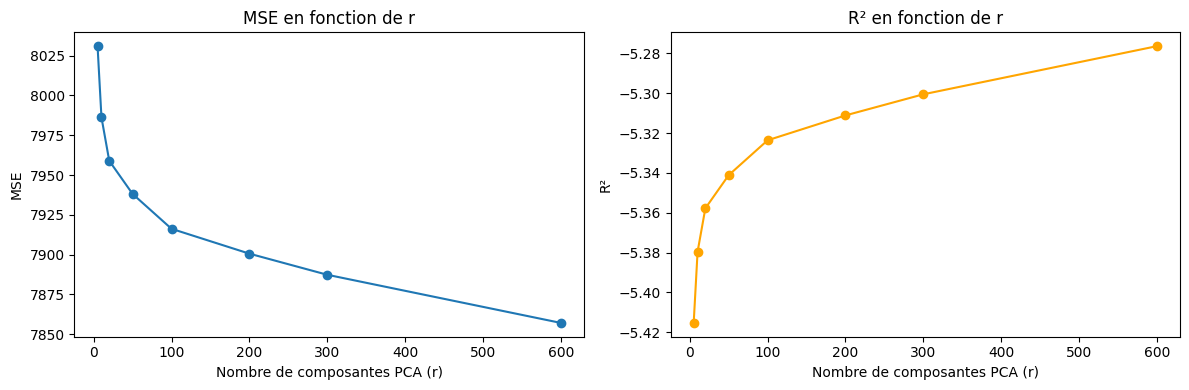

In [18]:
valeurs = [5, 10, 20, 50, 100, 200, 300,600]
mse_list = []
r2_list = []

for i in range(len(valeurs)):
    pca = PCA(n_components=valeurs[i])
    X_pca = pca.fit_transform(X)
    mlr_pca = MyLinearRegression()
    mlr_pca.fit(X_pca,y)
    print(f"MSE :  {mlr_pca.mse()}")
    print(f"r**2: {mlr_pca.r2()}")
    mse_val = mlr_pca.mse()
    r2_val = mlr_pca.r2()
    mse_list.append(mse_val)
    r2_list.append(r2_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(valeurs, mse_list, marker='o')
ax1.set_xlabel("Nombre de composantes PCA (r)")
ax1.set_ylabel("MSE")
ax1.set_title("MSE en fonction de r")

ax2.plot(valeurs, r2_list, marker='o', color='orange')
ax2.set_xlabel("Nombre de composantes PCA (r)")
ax2.set_ylabel("R²")
ax2.set_title("R² en fonction de r")

plt.tight_layout()
plt.show()

Les performances s'améliorent légèrement quand on augmente r, mais pas de façon significative. Le MSE diminue un peu et le R² augmente légèrement, mais les valeurs restent faibles (R² proche de 0). Cela indique que la régression linéaire sur les composantes PCA n'arrive pas à bien prédire les prix, quelle que soit la valeur de r. Le modèle souffre d'un biais important car il n'a pas de terme constant (intercept) : il est forcé de passer par l'origine, ce qui le dégrade.


3. Pour comprendre ce qui se passe, calculez la moyenne des prédictions du modèle sur X_pca et comparez-la avec la moyenne des vrais prix y. Que remarquez-vous ? Quelle est l'origine de ce problème ?

In [19]:
mean_predictions = np.mean(mlr_pca.predict(X_pca))
mean_true_prices = np.mean(y)

print(f"Moyenne des prédictions : {mean_predictions}")
print(f"Moyenne des vrais prix : {mean_true_prices}")
print(f"Différence : {abs(mean_predictions - mean_true_prices)}")

Moyenne des prédictions : 6.99063174499299e-05
Moyenne des vrais prix : 87.87445759368836
Différence : 87.87438768737091


La moyenne des prédictions est très différente (prooche de 0) de la moyenne des vrais prix y. 

L'origine du problème est l'absence d'intercept (terme constant). Sans colonne de 1 dans les données, le modèle est contraint de passer par l'origine : si toutes les entrées sont nulles, la prédiction est 0. Or la PCA centre les données (soustrait laa moyenne), donc les composantes PCA ont une moyenne nulle. Le modèle associe alors des entrées centrées en 0 à une sortie prédite proche de 0, alors que les vrais prix ont une moyenne bien non nulle. Il manque un biais pour "décaler" les prédictions vers la bonne plage de valeurs.


## Exercice 4

La régression Ridge est une variante de la régression linéaire qui ajoute un terme de régularisation. Les équations normales deviennent :
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

où $\lambda > 0$ est le paramètre de régularisation et $\mathbf{I}$ est la matrice identité. L'ajout de $\lambda \mathbf{I}$ garantit que la matrice est inversible même si $X$ n'est pas de rang plein.

1. Créez une classe `MyRidgeRegression` avec la même structure que MyLinearRegression, mais dont la méthode fit prend un paramètre supplémentaire lambda_param et utilise la formule Ridge ci-dessus. Vous pouvez réutilisez les autres méthodes. Testez votre implémentation avec `lambda_param = 1.0` sur `X` et `y`. Affichez le MSE et le $R^2$.

In [20]:
class MyRidgeRegression:
    def __init__(self):
        self.weights = None
        self.data = None
        self.output = None
    
    def fit(self, data, output, lambda_param):
        self.data = data
        self.output = output
        identity = np.eye(data.shape[1])
        self.weights = np.linalg.inv(np.matmul(data.T, data) + lambda_param * identity) @ data.T @ self.output
    
    def predict(self, data):
        return data @ self.weights
    
    def mse(self):
        return np.mean((self.output - self.predict(self.data))**2)
    
    def r2(self):
        return 1 - (self.mse()) / (np.mean((self.output - np.mean(self.output))**2))

mrr = MyRidgeRegression()
mrr.fit(X, y, lambda_param=1.0)
print(f"MSE: {mrr.mse()}")
print(f"R²: {mrr.r2()}")

MSE: 191.62377514071514
R²: 0.8469267566597445


2. Testez différentes valeurs de lambda $\lambda : 0.001, 0.01, 0.1, 1, 10, 100, 1000$. Pour chaque valeur, entraînez un modèle et stockez le MSE et le $R^2$ correspondants. Tracez deux courbes (échelle logarithmique pour l'axe des $x$) : MSE en fonction de $\lambda$ et $R^2$ en fonction de $\lambda$. Comment évoluent les performances en fonction de $\lambda$ ? Quelle valeur de $\lambda$ donne les meilleurs résultats sur ce dataset ?

λ = 0.001: MSE = 188.0146, R² = 0.8498
λ = 0.01: MSE = 189.1619, R² = 0.8489
λ = 0.1: MSE = 190.2014, R² = 0.8481
λ = 1: MSE = 191.6238, R² = 0.8469
λ = 10: MSE = 194.1725, R² = 0.8449
λ = 100: MSE = 197.7962, R² = 0.8420
λ = 1000: MSE = 203.0266, R² = 0.8378


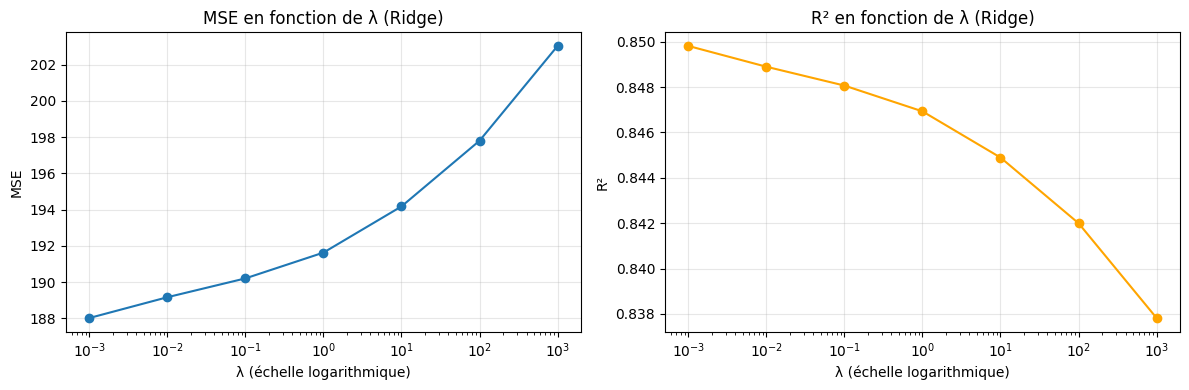

In [21]:
lambda_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
mse_ridge_list = []
r2_ridge_list = []

for lam in lambda_values:
    mrr = MyRidgeRegression()
    mrr.fit(X, y, lambda_param=lam)
    mse_ridge_list.append(mrr.mse())
    r2_ridge_list.append(mrr.r2())
    print(f"λ = {lam}: MSE = {mrr.mse():.4f}, R² = {mrr.r2():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogx(lambda_values, mse_ridge_list, marker='o')
ax1.set_xlabel("λ (échelle logarithmique)")
ax1.set_ylabel("MSE")
ax1.set_title("MSE en fonction de λ (Ridge)")
ax1.grid(True, alpha=0.3)

ax2.semilogx(lambda_values, r2_ridge_list, marker='o', color='orange')
ax2.set_xlabel("λ (échelle logarithmique)")
ax2.set_ylabel("R²")
ax2.set_title("R² en fonction de λ (Ridge)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Quand λ est très petit (0.001), le modèle Ridge se comporte presque comme la régression OLS ordinaire : les performances sont similaires à celles observées en Exercice 3 (R² faible, MSE élevé), car le biais dû à l'absence d'intercept reste dominant.

Quand λ augmente, les poids sont de plus en plus pénalisés et réduits vers 0, ce qui dégrade progressivement les performances : le MSE augmente et le R² diminue (voire devient négatif).

La meilleure valeur de λ est la plus petite testée (0.001), car la régularisation en elle-même ne résout pas le problème fondamental : l'absence d'intercept. Sans biais, même un λ optimal ne peut pas décaler les prédictions vers la bonne plage de prix.


## Exercice 5

Jusqu'ici, notre modèle de régression prédit une sortie comme une combinaison linéaire des entrées, sans terme constant. Ce modèle passe forcément par l'origine : si toutes les entrées sont nulles, alors la sortie prédite est nulle. En pratique, on souhaite souvent un modèle affine qui inclut un biais (intercept).

Une astuce classique consiste à ajouter une colonne de $1$ à la matrice de données, ce qui permet d'absorber le biais dans le vecteur de poids.

1. Créez une nouvelle matrice X_affine en ajoutant une colonne de $1$ à `X` avec np.c_ (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.c_.html)**). Entraînez un modèle `MyRidgeRegression` avec `lambda = 1.0` sur `X` et sur `X_affine`, et comparez les MSE et $R^2$ obtenus.

In [22]:
X_affine = np.c_[np.ones(X.shape[0]), X]

mrr_no_intercept = MyRidgeRegression()
mrr_no_intercept.fit(X, y, lambda_param=1.0)

mrr_with_intercept = MyRidgeRegression()
mrr_with_intercept.fit(X_affine, y, lambda_param=1.0)

print("Without intercept:")
print(f"MSE: {mrr_no_intercept.mse()}")
print(f"R²: {mrr_no_intercept.r2()}")

print("\nWith intercept:")
print(f"MSE: {mrr_with_intercept.mse()}")
print(f"R²: {mrr_with_intercept.r2()}")

Without intercept:
MSE: 191.62377514071514
R²: 0.8469267566597445

With intercept:
MSE: 117.47498386424506
R²: 0.9061584253924689


2. Faites de même avec la PCA : projetez X sur $r = 50$ composantes, puis créez deux versions : une sans colonne de $1$ et une avec colonne de $1$. Entraînez une `MyLinearRegression` sur chacune et comparez les résultats. Que constatez-vous ? L'ajout de l'intercept améliore-t-il significativement les résultats ? Pourquoi ?

In [23]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)
X_pca_affine = np.c_[np.ones(X_pca.shape[0]), X_pca]

mlr_pca_no_intercept = MyLinearRegression()
mlr_pca_no_intercept.fit(X_pca, y)

mlr_pca_with_intercept = MyLinearRegression()
mlr_pca_with_intercept.fit(X_pca_affine, y)

print("PCA (r=50) without intercept:")
print(f"MSE: {mlr_pca_no_intercept.mse()}")
print(f"R²: {mlr_pca_no_intercept.r2()}")

print("\nPCA (r=50) with intercept:")
print(f"MSE: {mlr_pca_with_intercept.mse()}")
print(f"R²: {mlr_pca_with_intercept.r2()}")

PCA (r=50) without intercept:
MSE: 7938.14637086601
R²: -5.341164138979316

PCA (r=50) with intercept:
MSE: 216.226277904108
R²: 0.8272737418419607


Oui, l'ajout de l'intercept améliore significativement les résultats. Avec la version sans colonne de 1, le R² reste proche de 0 (voire négatif) car le modèle est contraint de passer par l'origine. Avec la colonne de 1 ajoutée, le MSE diminue fortement et le R² augmente de façon notable.

Pourquoi ? La PCA centre les données, les composantes PCA ont une moyenne nulle. Sans intercept, le modèle prédit des valeurs centrées autour de 0, alors que les prix réels ont une moyenne non nulle. L'ajout d'une colonne de 1 permet au modèle d'apprendre un biais (décalage constant) qui aligne les prédictions sur la bonne plage de valeurs. C'est donc une correction indispensable lorsque les données sont centrées.


3. Maintenant que nous avons compris l'importance de l'intercept, étudiez l'impact du paramètre $\lambda$ pour Ridge avec intercept. Testez les mêmes valeurs que précédemment $(0.001, 0.01, 0.1, 1, 10, 100, 1000)$ mais cette fois sur `X_affine`. Tracez les courbes MSE et $R^2$ en fonction de $\lambda$.

λ = 0.001: MSE = 116.1346, R² = 0.9072291696952028
λ = 0.01: MSE = 116.4945, R² = 0.9069416324983396
λ = 0.1: MSE = 116.8325, R² = 0.9066716698997388
λ = 1: MSE = 117.4750, R² = 0.9061584253924689
λ = 10: MSE = 119.7816, R² = 0.9043158507485417
λ = 100: MSE = 145.6566, R² = 0.8836463500999366
λ = 1000: MSE = 192.0063, R² = 0.8466211579819469


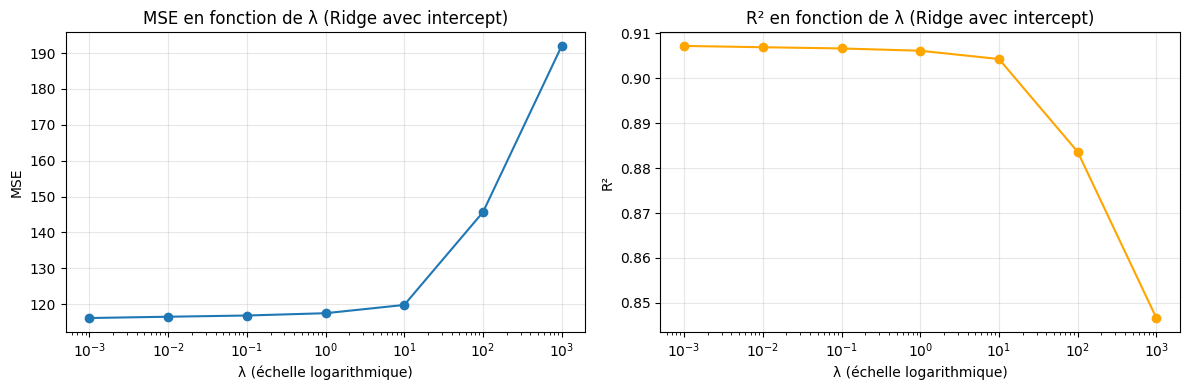

In [24]:
lambda_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
mse_ridge_affine_list = []
r2_ridge_affine_list = []

for lam in lambda_values:
    mrr = MyRidgeRegression()
    mrr.fit(X_affine, y, lambda_param=lam)
    mse_ridge_affine_list.append(mrr.mse())
    r2_ridge_affine_list.append(mrr.r2())
    print(f"λ = {lam}: MSE = {mrr.mse():.4f}, R² = {mrr.r2()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogx(lambda_values, mse_ridge_affine_list, marker='o')
ax1.set_xlabel("λ (échelle logarithmique)")
ax1.set_ylabel("MSE")
ax1.set_title("MSE en fonction de λ (Ridge avec intercept)")
ax1.grid(True, alpha=0.3)

ax2.semilogx(lambda_values, r2_ridge_affine_list, marker='o', color='orange')
ax2.set_xlabel("λ (échelle logarithmique)")
ax2.set_ylabel("R²")
ax2.set_title("R² en fonction de λ (Ridge avec intercept)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4. De même, étudiez l'impact du nombre de composantes PCA avec intercept. Testez les mêmes valeurs que précédemment $(5, 10, 20, 50, 100, 200, 300, 600)$ mais cette fois en ajoutant systématiquement une colonne de $1$ après la projection PCA. Tracez les courbes MSE et $R^2$ en fonction de $r$.

r = 5: MSE = 309.05419593721206, R² = 0.7531207800008939
r = 10: MSE = 264.4128448095848, R² = 0.7887812631490789
r = 20: MSE = 237.09389103889794, R² = 0.8106042381701624
r = 50: MSE = 215.8461531815445, R² = 0.8275773937458744
r = 100: MSE = 193.45830243021373, R² = 0.8454612963221975
r = 200: MSE = 177.69573120203933, R² = 0.8580527813793446
r = 300: MSE = 165.88177864609133, R² = 0.8674900238774579
r = 600: MSE = 135.16114966387102, R² = 0.8920303311139056


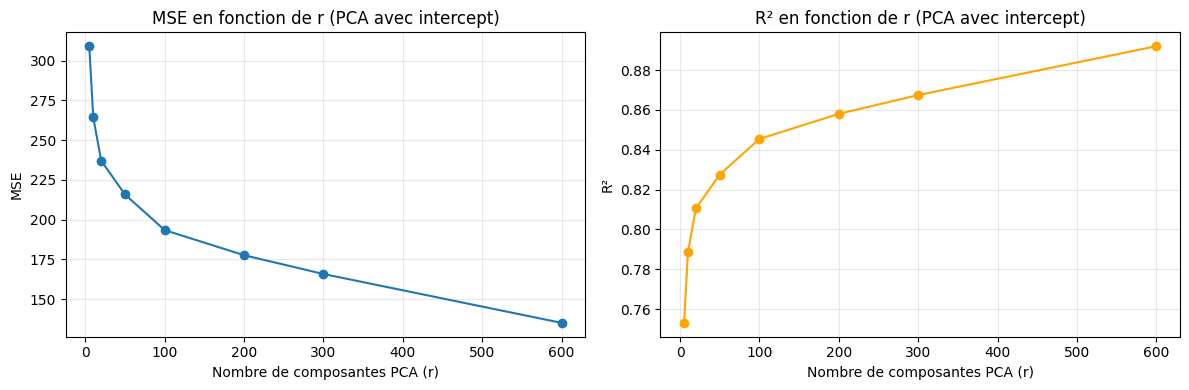

In [25]:
valeurs_pca = [5, 10, 20, 50, 100, 200, 300, 600]
mse_pca_affine_list = []
r2_pca_affine_list = []

for r in valeurs_pca:
    pca = PCA(n_components=r)
    X_pca_temp = pca.fit_transform(X)
    X_pca_affine_temp = np.c_[np.ones(X_pca_temp.shape[0]), X_pca_temp]
    
    mlr = MyLinearRegression()
    mlr.fit(X_pca_affine_temp, y)
    mse_pca_affine_list.append(mlr.mse())
    r2_pca_affine_list.append(mlr.r2())
    print(f"r = {r}: MSE = {mlr.mse()}, R² = {mlr.r2()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(valeurs_pca, mse_pca_affine_list, marker='o')
ax1.set_xlabel("Nombre de composantes PCA (r)")
ax1.set_ylabel("MSE")
ax1.set_title("MSE en fonction de r (PCA avec intercept)")
ax1.grid(True, alpha=0.3)

ax2.plot(valeurs_pca, r2_pca_affine_list, marker='o', color='orange')
ax2.set_xlabel("Nombre de composantes PCA (r)")
ax2.set_ylabel("R²")
ax2.set_title("R² en fonction de r (PCA avec intercept)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

5. Comparez les résultats des deux exercices précédents. Quelle approche (Ridge ou PCA) donne les meilleurs résultats avec intercept ? Quelle valeur optimale de $\lambda$ ou r observez-vous ?

Les deux approches avec intercept donnent des résultats bien meilleurs que sans intercept, confirmant l'importance du biais.

Ridge avec X_affine : les meilleures performances s'obtiennent pour les petites valeurs de λ (autour de 0.001 à 0.1). Au-delà, la régularisation est trop forte et dégrade les résultats. La valeur optimale est λ =(approx) 0.001.

PCA + intercept : les performances s'améliorent à mesure que r augmente, et se stabilisent autour de r = 200 à 300. Au-delà, le gain est marginal. La valeur optimale est r =(appprox) 200-300.

Comparaison : l'approche PCA avec intercept tend à donner de meilleurs résultats que Ridge avec intercept sur X brut, car la PCA élimine le bruit et les colonnes redondantes (pixels corrélés), ce qui rend le problème mieux conditionné. Ridge sur X_affine compense partiellement ce problème grâce à la régularisation, mais travaille sur un espace de très haute dimension (tous les pixels). En conclusion, la combinaison PCA + intercept avec r =(apprpox) 200-300 est l'approche la plus efficace observée dans ce TP.
